# Notebook 05: Evaluation Analysis

**Objective**: Comprehensive evaluation and error analysis of the best performing age-gender CNN model.

**Sections**:
1. **Test Set Evaluation**: Performance metrics on held-out test data
2. **Gender Analysis**: Confusion matrix and per-class metrics
3. **Age Error Analysis**: Error distribution and patterns by demographics
4. **Failure Case Analysis**: Worst predictions and visualization
5. **Cross-Dataset Evaluation**: Generalization testing (Adience dataset if available)
6. **Ethical Considerations**: Dataset biases and model limitations

**Implementation Checklist Mapping**:
- ✅ Phase 6: Model Evaluation
- ✅ Phase 7: Error Analysis
- ✅ Phase 8: Ethical Documentation

## Setup and Imports

In [1]:
%pip install -q torch torchvision numpy pandas scikit-learn albumentations opencv-python matplotlib seaborn tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

import torch
from torch.utils.data import DataLoader

# Add src to path
def find_project_root():
    current = Path.cwd()
    while current != current.parent:
        if (current / 'src').exists():
            return current
        current = current.parent
    return Path.cwd()

project_root = find_project_root()
sys.path.insert(0, str(project_root / 'src'))

from data.load_utkface import UTKFaceDataset
from data.load_adience import AdienceDataset, adience_collate_fn
from data.preprocessing import get_inference_transforms
from models.multitask_model import AgeGenderModel
from training.evaluate import evaluate_model, evaluate_adience
from utils.metrics import (
    calculate_gender_confusion_matrix,
    calculate_metrics_by_age_range,
    calculate_metrics_by_gender,
    calculate_within_range_accuracy,
    calculate_bin_tolerance_accuracy,
    map_ages_to_bins,
    calculate_age_bin_accuracy,
    ADIENCE_BIN_ORDER,
    ADIENCE_BIN_RANGES,
)
from utils.visualization import (
    plot_confusion_matrix,
    plot_age_error_distribution,
    plot_predictions_vs_actual,
    visualize_sample_predictions,
    plot_metrics_by_age_range
)
from utils.config import load_experiment_results

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")


Project root: c:\Users\Mark\Projects\age-gender-cnn
PyTorch version: 2.5.1+cu121


In [3]:
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set seeds
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"Using device: {DEVICE}")

Using device: cuda


## Load Best Model from Experiments

In [4]:
# ── Discover all experiment result files ──────────────────────────────────────
# Group by experiment ID (strip timestamp suffix), keep the most recent file
# per experiment so exp05-exp09 are included alongside exp01-exp04.

exp_dir = project_root / 'experiments'

# e.g. "exp01_baseline_results_20260302T041332Z.json"  →  id = "exp01_baseline"
# e.g. "exp01_baseline_results.json"                   →  id = "exp01_baseline"
id_pattern = re.compile(r'^(exp\d+_[^_]+(?:_[^_]+)*)_results')

latest_files = {}  # exp_id → Path (sorted alphabetically, last timestamp wins)
for fpath in sorted(exp_dir.glob('exp*_results*.json')):
    m = id_pattern.match(fpath.stem)
    if m:
        exp_id = m.group(1)
        latest_files[exp_id] = fpath  # later sort order overwrites earlier

# ── Load results & build comparison table ─────────────────────────────────────
results_summary = []
for exp_id, fpath in sorted(latest_files.items()):
    try:
        data = load_experiment_results(str(fpath))
        results_summary.append({
            'exp_id':      exp_id,
            'age_mae':     data['metrics']['age_mae'],
            'gender_acc':  data['metrics']['gender_accuracy'],
            'source_file': fpath.name,
        })
    except Exception as e:
        print(f"  ⚠ Could not load {fpath.name}: {e}")

summary_df = (
    pd.DataFrame(results_summary)
    .sort_values('age_mae')
    .reset_index(drop=True)
)
summary_df.index += 1  # 1-based rank

print("All experiments ranked by Age MAE (↓ lower is better):\n")
print(summary_df[['exp_id', 'age_mae', 'gender_acc']].to_string(
    float_format=lambda x: f"{x:.4f}"
))

# ── Select best checkpoint ─────────────────────────────────────────────────────
best_exp = summary_df.iloc[0]
best_exp_id  = best_exp['exp_id']
best_age_mae = best_exp['age_mae']
best_gen_acc = best_exp['gender_acc']

checkpoint_path = project_root / 'models' / f"{best_exp_id}_best.pth"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)

best_model = AgeGenderModel().to(DEVICE)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()

print(f"\n✓ Best model : {best_exp_id}")
print(f"  Age MAE    : {best_age_mae:.4f} years")
print(f"  Gender Acc : {best_gen_acc:.4f}")
print(f"  Checkpoint : {checkpoint_path.name}")
print(f"  Trained for: {checkpoint.get('epoch', '?')} epochs")


All experiments ranked by Age MAE (↓ lower is better):

                      exp_id  age_mae  gender_acc
1          exp06_lr_schedule   4.8569      0.9296
2    exp08_balanced_sampling   4.8893      0.9262
3             exp01_baseline   4.9548      0.9267
4  exp07_extended_early_stop   5.0043      0.9205
5          exp02_age_focused   5.0123      0.9137
6          exp04_minimal_aug   5.0160      0.9237
7      exp09_label_smoothing   5.0581      0.9115
8      exp03_conservative_lr   5.1003      0.9179
9         exp05_high_dropout   5.1146      0.9207

✓ Best model : exp06_lr_schedule
  Age MAE    : 4.8569 years
  Gender Acc : 0.9296
  Checkpoint : exp06_lr_schedule_best.pth
  Trained for: 20 epochs


## Test Set Evaluation

In [5]:
# Load test split
with open(project_root / 'dataset' / 'processed' / 'utkface_splits.json', 'r') as f:
    splits = json.load(f)

test_idx = splits['test']
print(f"Test set size: {len(test_idx)}")

PROCESSED_ROOT = project_root / 'dataset' / 'processed'

# Create test dataset and loader
metadata_candidates = sorted(PROCESSED_ROOT.glob("utkface_metadata_*.csv"))
if not metadata_candidates:
    raise FileNotFoundError(
        f"No metadata CSV found in {PROCESSED_ROOT}.\n"
        "Please run notebook 01_dataset_exploration.ipynb first to generate metadata."
    )

# Use the most recent metadata file
metadata_path = metadata_candidates[-1]
image_dir = project_root / 'dataset' / 'raw' / 'UTKFace'

test_dataset = UTKFaceDataset(
    metadata_path=str(metadata_path),
    image_dir=str(image_dir),
    split_indices=test_idx,
    transform=get_inference_transforms()
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

Test set size: 7172


In [6]:
# Run evaluation
age_preds, gender_preds, age_targets, gender_targets, test_metrics = evaluate_model(
    best_model, test_loader, DEVICE, verbose=True
)

print(f"\\n{'='*60}")
print("TEST SET RESULTS")
print(f"{'='*60}")
print(f"Age MAE: {test_metrics['age_mae']:.2f} years")
print(f"Gender Accuracy: {test_metrics['gender_accuracy']:.4f} ({test_metrics['gender_accuracy']*100:.2f}%)")

Evaluating: 100%|██████████| 225/225 [00:46<00:00,  4.87it/s]


Evaluation Results:
  Age MAE: 4.84 years
  Gender Accuracy: 0.9272 (92.72%)
\n============================================================
TEST SET RESULTS
Age MAE: 4.84 years
Gender Accuracy: 0.9272 (92.72%)


## Gender Classification Analysis

Gender Confusion Matrix:
[[3464  282]
 [ 240 3186]]

True Negatives (Male predicted as Male): 3464
False Positives (Male predicted as Female): 282
False Negatives (Female predicted as Male): 240
True Positives (Female predicted as Female): 3186
Saved confusion matrix to c:\Users\Mark\Projects\age-gender-cnn\experiments\gender_confusion_matrix.png


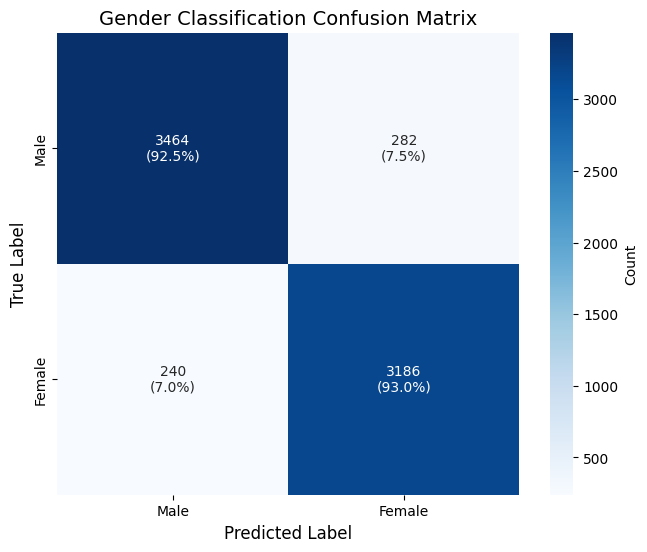

In [7]:
# Compute confusion matrix
cm = calculate_gender_confusion_matrix(gender_preds, gender_targets)

print("Gender Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives (Male predicted as Male): {cm[0, 0]}")
print(f"False Positives (Male predicted as Female): {cm[0, 1]}")
print(f"False Negatives (Female predicted as Male): {cm[1, 0]}")
print(f"True Positives (Female predicted as Female): {cm[1, 1]}")

# Visualize
plot_confusion_matrix(
    cm,
    labels=['Male', 'Female'],
    save_path=str(project_root / 'experiments' / 'gender_confusion_matrix.png')
)

In [8]:
# ── Gender Classification Report ──────────────────────────────────────────────
from sklearn.metrics import classification_report, precision_recall_fscore_support

gender_pred_labels = (gender_preds > 0.5).astype(int)

report_str = classification_report(
    gender_targets, gender_pred_labels,
    target_names=['Male (0)', 'Female (1)']
)
print("Gender Classification Report:")
print(report_str)

# Structured as a DataFrame for easier reading
precision, recall, f1, support = precision_recall_fscore_support(
    gender_targets, gender_pred_labels, labels=[0, 1]
)
gender_report_df = pd.DataFrame({
    'Precision': precision,
    'Recall':    recall,
    'F1-Score':  f1,
    'Support':   support.astype(int),
}, index=['Male (0)', 'Female (1)'])

print("Structured breakdown:")
display(gender_report_df.style.format({'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1-Score': '{:.4f}'}))


Gender Classification Report:
              precision    recall  f1-score   support

    Male (0)       0.94      0.92      0.93      3746
  Female (1)       0.92      0.93      0.92      3426

    accuracy                           0.93      7172
   macro avg       0.93      0.93      0.93      7172
weighted avg       0.93      0.93      0.93      7172

Structured breakdown:


,Precision,Recall,F1-Score,Support
Male (0),0.9352,0.9247,0.9299,3746
Female (1),0.9187,0.9299,0.9243,3426


## Age Prediction Error Analysis


Age Error Statistics:
  Mean Error: -0.40 years
  Mean Absolute Error: 4.84 years
  Std Deviation: 7.14 years
  Median Error: 0.05 years
  Max Over-estimation: 52.62 years
  Max Under-estimation: -83.99 years
Saved error distribution to c:\Users\Mark\Projects\age-gender-cnn\experiments\age_error_distribution.png


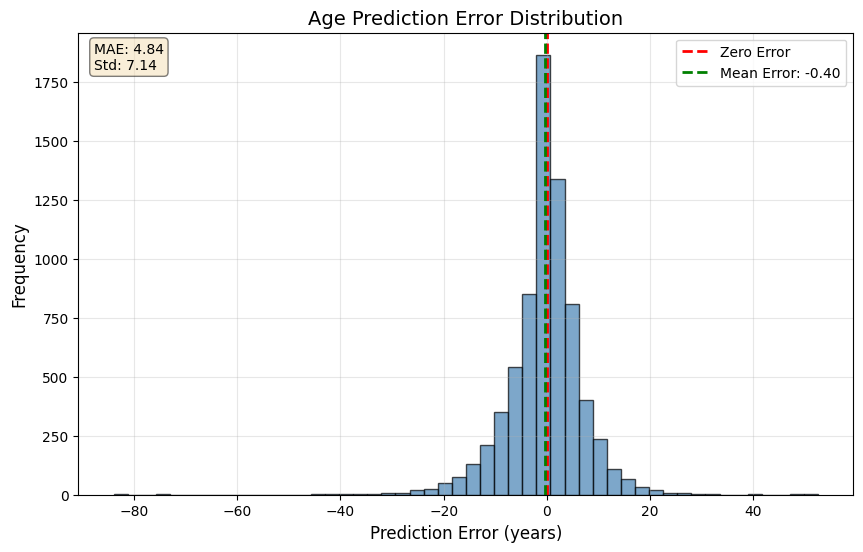

In [9]:
# Calculate errors
age_errors = age_preds - age_targets

print(f"Age Error Statistics:")
print(f"  Mean Error: {np.mean(age_errors):.2f} years")
print(f"  Mean Absolute Error: {np.mean(np.abs(age_errors)):.2f} years")
print(f"  Std Deviation: {np.std(age_errors):.2f} years")
print(f"  Median Error: {np.median(age_errors):.2f} years")
print(f"  Max Over-estimation: {np.max(age_errors):.2f} years")
print(f"  Max Under-estimation: {np.min(age_errors):.2f} years")

# Plot error distribution
plot_age_error_distribution(
    age_errors,
    save_path=str(project_root / 'experiments' / 'age_error_distribution.png')
)

Saved predictions vs actual plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\age_predictions_vs_actual.png


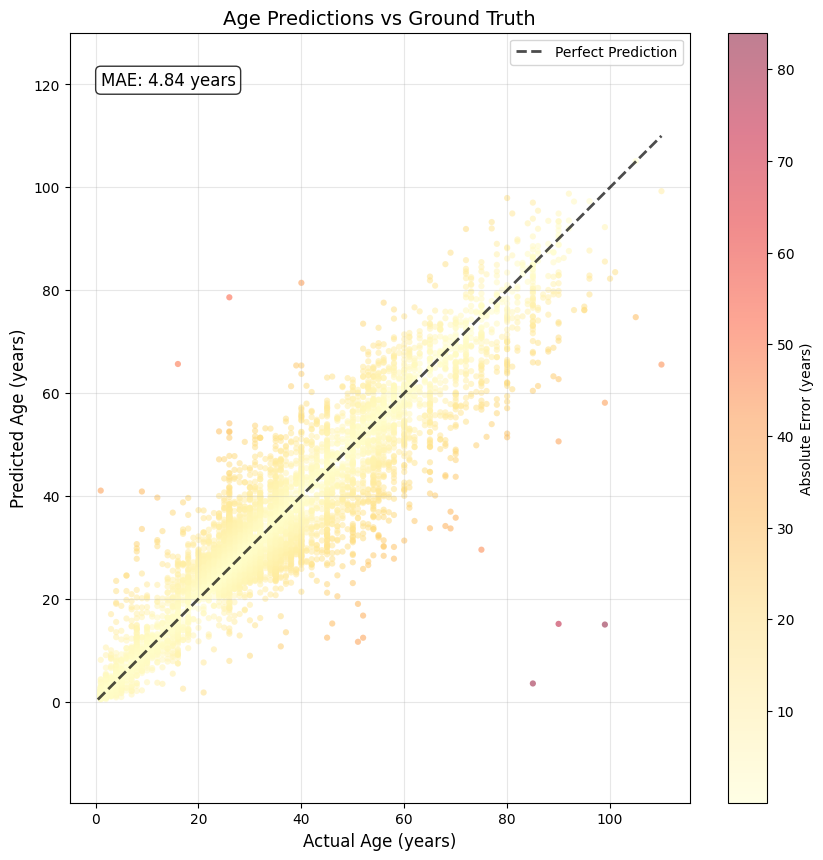

In [10]:
# Scatter plot of predictions vs ground truth
plot_predictions_vs_actual(
    age_preds,
    age_targets,
    save_path=str(project_root / 'experiments' / 'age_predictions_vs_actual.png')
)

\nPerformance by Age Range:
  0-20: MAE = 2.76 years (n=1508)
  21-40: MAE = 4.21 years (n=3642)
  41-60: MAE = 7.11 years (n=1295)
  61-120: MAE = 8.29 years (n=727)
Saved age range metrics to c:\Users\Mark\Projects\age-gender-cnn\experiments\age_metrics_by_range.png


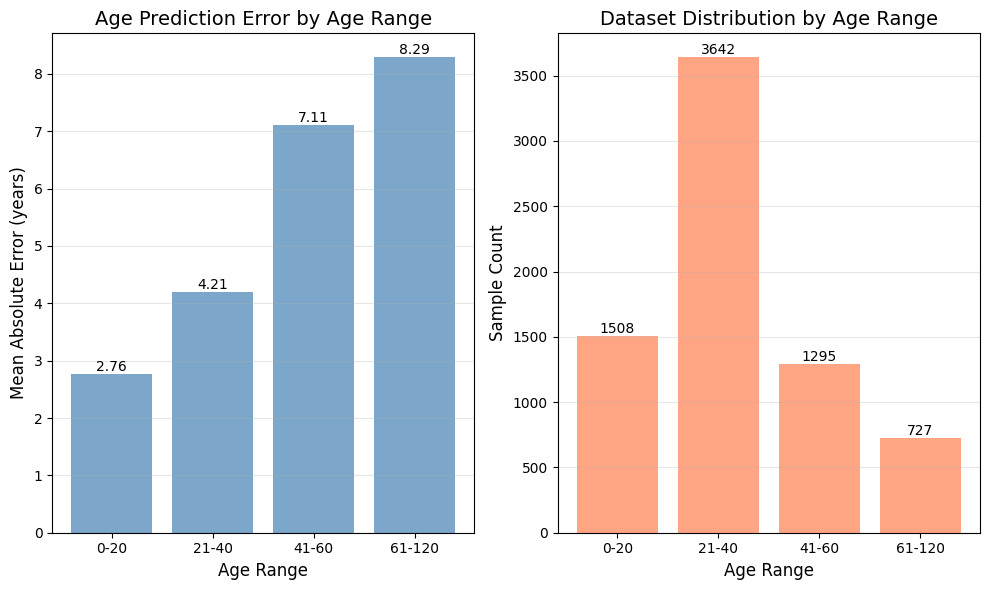

In [11]:
# Calculate metrics by age range
age_range_metrics = calculate_metrics_by_age_range(age_preds, age_targets)

print(f"\\nPerformance by Age Range:")
for age_range, metrics in age_range_metrics.items():
    print(f"  {age_range}: MAE = {metrics['mae']:.2f} years (n={metrics['count']})")

# Visualize
plot_metrics_by_age_range(
    age_range_metrics,
    save_path=str(project_root / 'experiments' / 'age_metrics_by_range.png')
)

\nAge Prediction by Gender:
  Male: MAE = 4.94 years (n=3746)
  Female: MAE = 4.74 years (n=3426)


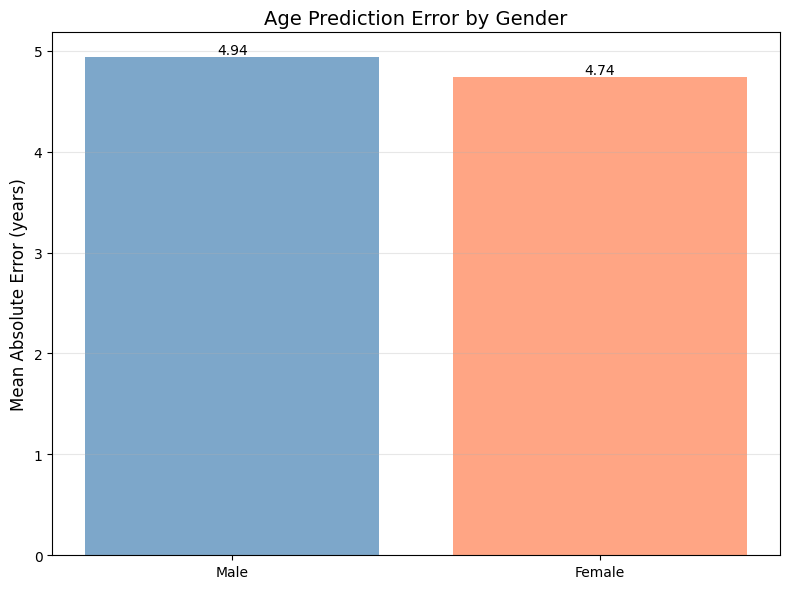

In [12]:
# Calculate metrics by gender
gender_metrics = calculate_metrics_by_gender(age_preds, age_targets, gender_targets)

print(f"\\nAge Prediction by Gender:")
for gender, metrics in gender_metrics.items():
    print(f"  {gender}: MAE = {metrics['mae']:.2f} years (n={metrics['count']})")

# Visualize comparison
fig, ax = plt.subplots(figsize=(8, 6))
genders = list(gender_metrics.keys())
maes = [gender_metrics[g]['mae'] for g in genders]

bars = ax.bar(genders, maes, color=['steelblue', 'coral'], alpha=0.7)
ax.set_ylabel('Mean Absolute Error (years)', fontsize=12)
ax.set_title('Age Prediction Error by Gender', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

for bar, mae in zip(bars, maes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mae:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(project_root / 'experiments' / 'age_error_by_gender.png', dpi=300)
plt.show()

## Adience-Style Age-Bin Accuracy (UTKFace Test Set)

Before running the full cross-dataset evaluation, we evaluate the same metrics on
the UTKFace test set — where we have continuous ground-truth ages — as a **baseline
proxy**. This lets us compare UTKFace↔Adience performance using the same metric.

Three complementary bin metrics are reported:

| Metric | What it measures |
|--------|-----------------|
| **Exact-bin match** | Predicted **and** true continuous age map to the same bin via the same `map_age_to_adience_bin()` function |
| **Within-range accuracy** | Predicted continuous age falls **inside the strict numeric range** of the true bin (primary Adience metric) |
| **±1-bin tolerance** | Predicted bin is at most one position away in the ordered bin list (accounts for boundary/gap cases) |


In [13]:
# ── Map both predicted and true ages to Adience bins ──────────────────────────
pred_bins_utk  = map_ages_to_bins(age_preds)
true_bins_utk  = map_ages_to_bins(age_targets)

exact_match_acc  = calculate_age_bin_accuracy(pred_bins_utk, true_bins_utk)
within_range_acc = calculate_within_range_accuracy(age_preds, true_bins_utk)
tol1_acc         = calculate_bin_tolerance_accuracy(pred_bins_utk, true_bins_utk, tolerance=1)

print("UTKFace Test Set — Adience-Style Bin Metrics")
print(f"  Exact-bin match accuracy  : {exact_match_acc:.4f}  ({exact_match_acc*100:.2f}%)")
print(f"  Within-range accuracy     : {within_range_acc:.4f}  ({within_range_acc*100:.2f}%)  ← primary")
print(f"  ±1-bin tolerance accuracy : {tol1_acc:.4f}  ({tol1_acc*100:.2f}%)")

# ── Per-bin breakdown ──────────────────────────────────────────────────────────
bin_rows = []
for bin_label in ADIENCE_BIN_ORDER:
    lo, hi = ADIENCE_BIN_RANGES[bin_label]
    idx = [i for i, b in enumerate(true_bins_utk) if b == bin_label]
    if not idx:
        bin_rows.append({'Bin': bin_label, 'Samples': 0,
                         'Within-Range %': float('nan'), 'Exact-Match %': float('nan')})
        continue
    sub_preds = age_preds[idx]
    sub_true_bins = [true_bins_utk[i] for i in idx]
    sub_pred_bins = [pred_bins_utk[i] for i in idx]
    wr = calculate_within_range_accuracy(sub_preds, sub_true_bins)
    em = calculate_age_bin_accuracy(sub_pred_bins, sub_true_bins)
    bin_rows.append({
        'Bin':           bin_label,
        'Samples':       len(idx),
        'Within-Range %': wr * 100,
        'Exact-Match %':  em * 100,
    })

bin_df = pd.DataFrame(bin_rows).set_index('Bin')
print("\nPer-bin breakdown:")
display(bin_df.style.format({
    'Samples':        '{:.0f}',
    'Within-Range %': '{:.1f}',
    'Exact-Match %':  '{:.1f}',
}).bar(subset=['Within-Range %', 'Exact-Match %'], vmin=0, vmax=100))


UTKFace Test Set — Adience-Style Bin Metrics
  Exact-bin match accuracy  : 0.6741  (67.41%)
  Within-range accuracy     : 0.4671  (46.71%)  ← primary
  ±1-bin tolerance accuracy : 0.9633  (96.33%)

Per-bin breakdown:


,Samples,Within-Range %,Exact-Match %
Bin,,,
0-2,588,76.4,90.5
4-6,223,26.9,48.9
8-13,325,50.5,65.2
15-20,580,14.7,28.8
25-32,2879,56.8,83.4
38-43,888,19.8,39.5
48-53,733,19.5,42.0
60+,956,66.8,79.1


## Failure Case Analysis

In [14]:
# Find worst predictions (largest absolute errors)
abs_errors = np.abs(age_errors)
worst_indices = np.argsort(abs_errors)[-20:]  # Top 20 worst

print(f"Top 20 Worst Age Predictions:")
for idx in worst_indices[::-1][:10]:  # Show first 10
    print(f"  True: {age_targets[idx]:.0f}y, Pred: {age_preds[idx]:.0f}y, Error: {age_errors[idx]:.1f}y")

# Load worst prediction images for visualization
worst_samples = []
metadata = pd.read_csv(metadata_path)
test_metadata = metadata.iloc[test_idx]

for idx in worst_indices[-10:][::-1]:  # Top 10 worst
    actual_idx = test_idx[idx]
    img_filename = metadata.iloc[actual_idx]['filename']
    worst_samples.append({
        'index': idx,
        'filename': img_filename,
        'true_age': age_targets[idx],
        'pred_age': age_preds[idx],
        'error': age_errors[idx]
    })

worst_df = pd.DataFrame(worst_samples)
display(worst_df)

Top 20 Worst Age Predictions:
  True: 99y, Pred: 15y, Error: -84.0y
  True: 85y, Pred: 4y, Error: -81.4y
  True: 90y, Pred: 15y, Error: -74.9y
  True: 26y, Pred: 79y, Error: 52.6y
  True: 16y, Pred: 66y, Error: 49.7y
  True: 75y, Pred: 30y, Error: -45.4y
  True: 110y, Pred: 66y, Error: -44.4y
  True: 40y, Pred: 81y, Error: 41.4y
  True: 99y, Pred: 58y, Error: -40.9y
  True: 1y, Pred: 41y, Error: 40.1y


,index,filename,true_age,pred_age,error
0,5924,99_1_2_20170110182418864.jpg,99.0,15.013584,-83.986416
1,2702,85_1_0_20170110181049060.jpg,85.0,3.560276,-81.439724
2,5019,90_1_0_20170120221911645.jpg,90.0,15.143107,-74.856893
3,6917,26_0_0_20170113210319768.jpg.chip.jpg,26.0,78.624519,52.624519
4,1119,16_0_0_20170110232108336.jpg,16.0,65.661896,49.661896
5,636,75_0_2_20170112202930960.jpg,75.0,29.564505,-45.435495
6,2037,110_1_0_20170120134701015.jpg.chip.jpg,110.0,65.553215,-44.446785
7,2801,40_0_0_20170113210319647.jpg.chip.jpg,40.0,81.439949,41.439949
8,5226,99_1_0_20170120221920654.jpg,99.0,58.129646,-40.870354
9,1623,1_0_4_20161221193041157.jpg.chip.jpg,1.0,41.054138,40.054138


Saved sample predictions to c:\Users\Mark\Projects\age-gender-cnn\experiments\sample_predictions.png


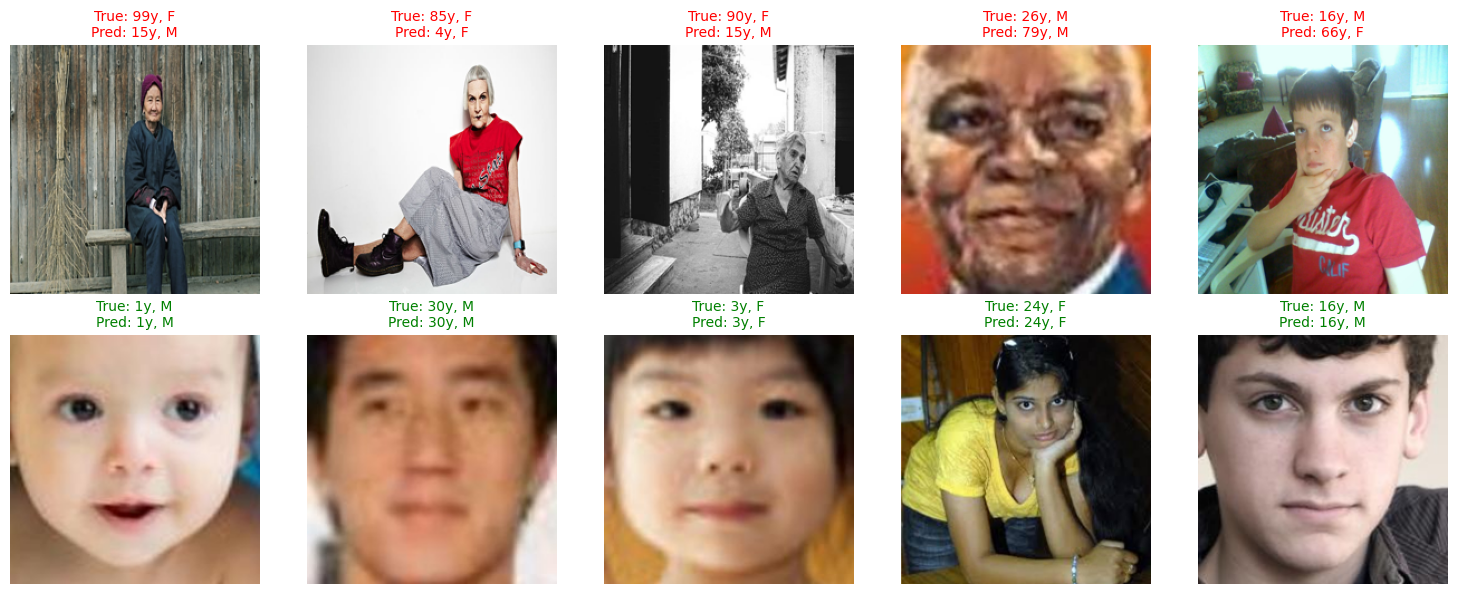

In [16]:
# Visualize sample predictions (mix of good and bad)
# Get a mix: 5 worst, 5 best
best_indices = np.argsort(abs_errors)[:5]
sample_indices = np.concatenate([worst_indices[-5:][::-1], best_indices])

# Load images — resize to 224×224 so they can be stacked into a uniform array
from PIL import Image

TARGET_SIZE = (224, 224)  # must match model input size
sample_images = []
for idx in sample_indices:
    actual_idx = test_idx[idx]
    img_path = image_dir / metadata.iloc[actual_idx]['filename']
    img = np.array(Image.open(img_path).convert('RGB').resize(TARGET_SIZE), dtype=np.uint8)
    sample_images.append(img)

sample_images = np.array(sample_images)  # shape: (10, 224, 224, 3)
sample_ages = age_targets[sample_indices]
sample_genders = gender_targets[sample_indices]
sample_age_preds = age_preds[sample_indices]
sample_gender_preds = gender_preds[sample_indices]

visualize_sample_predictions(
    sample_images,
    sample_ages,
    sample_genders,
    sample_age_preds,
    sample_gender_preds,
    num_samples=10,
    save_path=str(project_root / 'experiments' / 'sample_predictions.png'),
    denormalize=False
)


## Cross-Dataset Evaluation (Adience)

We test generalisation by running the same trained model on the Adience benchmark —
a completely separate dataset collected from Flickr albums, with different image
quality, pose variation, and annotation style.

### Key differences vs UTKFace

| | UTKFace (primary) | Adience (secondary) |
|---|---|---|
| Labels | Continuous age (0–116) | 8 age-group bins |
| Images | Aligned, uniform quality | Unfiltered, high variation |
| Size | ~23 k | ~26 k |
| Primary metric | MAE (years) | Within-range accuracy |

### Evaluation protocol

Both datasets share **exactly the same preprocessing pipeline** (`get_inference_transforms()`):
resize → ImageNet normalise.

Because Adience labels are bins rather than exact ages, we evaluate with
two metrics (computed on the predicted **continuous** age):

- **Within-range accuracy** — is the predicted age inside the strict numeric
  range of the true bin? (e.g. '25-32' → predicted in [25, 32])
- **±1-bin tolerance** — is the predicted bin at most one position away
  in the ordered bin list? (accounts for gap regions between bins)

Gender accuracy is directly comparable to UTKFace since both use binary labels.


In [17]:
from utils.metrics import calculate_gender_accuracy

ADIENCE_IMAGE_DIR = project_root / 'dataset' / 'raw' / 'Adience'
ADIENCE_FOLD_DIR  = ADIENCE_IMAGE_DIR / 'fold_data'

if not ADIENCE_FOLD_DIR.exists():
    print("⚠  Adience fold files not found.")
    print(f"   Expected: {ADIENCE_FOLD_DIR}")
    print("   Download from: https://talhassner.github.io/home/projects/Adience/Adience-data.html")
    print("   Place fold_0_data.txt … fold_4_data.txt inside the fold_data/ subfolder.")
else:
    # ── Build dataset & dataloader (shared preprocessing pipeline) ────────────
    adience_dataset = AdienceDataset(
        fold_dir=ADIENCE_FOLD_DIR,
        image_dir=ADIENCE_IMAGE_DIR,
    )
    adience_loader = DataLoader(
        adience_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=adience_collate_fn,
    )

    print(f"Adience dataset loaded: {len(adience_dataset):,} valid samples")
    print("\nBin distribution:")
    display(adience_dataset.get_bin_distribution().to_frame('count').T)

    # ── Run inference ─────────────────────────────────────────────────────────
    age_preds_a, gender_preds_a, true_bins_a, true_genders_a = evaluate_adience(
        best_model, adience_loader, DEVICE, verbose=True
    )

    # ── Compute Adience metrics ────────────────────────────────────────────────
    pred_bins_a      = map_ages_to_bins(age_preds_a)
    within_range_a   = calculate_within_range_accuracy(age_preds_a, true_bins_a)
    tol1_acc_a       = calculate_bin_tolerance_accuracy(pred_bins_a, true_bins_a, tolerance=1)
    exact_match_a    = calculate_age_bin_accuracy(pred_bins_a, true_bins_a)
    gender_acc_a     = calculate_gender_accuracy(gender_preds_a, true_genders_a)

    print(f"\nAdience Test Results:")
    print(f"  Within-range accuracy (primary) : {within_range_a:.4f}  ({within_range_a*100:.2f}%)")
    print(f"  ±1-bin tolerance accuracy       : {tol1_acc_a:.4f}  ({tol1_acc_a*100:.2f}%)")
    print(f"  Exact-bin match accuracy        : {exact_match_a:.4f}  ({exact_match_a*100:.2f}%)")
    print(f"  Gender accuracy                 : {gender_acc_a:.4f}  ({gender_acc_a*100:.2f}%)")

    # ── UTKFace vs Adience comparison table ────────────────────────────────────
    comparison_data = {
        'UTKFace (test)': {
            'Age MAE (years)':        f"{test_metrics['age_mae']:.2f}",
            'Within-range acc':       f"{within_range_acc*100:.2f}%",
            '±1-bin tolerance acc':   f"{tol1_acc*100:.2f}%",
            'Gender accuracy':        f"{test_metrics['gender_accuracy']*100:.2f}%",
        },
        'Adience (cross-dataset)': {
            'Age MAE (years)':        'N/A (no ground-truth ages)',
            'Within-range acc':       f"{within_range_a*100:.2f}%",
            '±1-bin tolerance acc':   f"{tol1_acc_a*100:.2f}%",
            'Gender accuracy':        f"{gender_acc_a*100:.2f}%",
        },
    }
    comparison_df = pd.DataFrame(comparison_data).T
    print("\nDataset Comparison:")
    display(comparison_df)

    # ── Per-bin Adience breakdown ──────────────────────────────────────────────
    adience_bin_rows = []
    for bin_label in ADIENCE_BIN_ORDER:
        idx = [i for i, b in enumerate(true_bins_a) if b == bin_label]
        if not idx:
            adience_bin_rows.append({'Bin': bin_label, 'Samples': 0,
                                     'Within-Range %': float('nan'),
                                     'Exact-Match %': float('nan')})
            continue
        sub_preds = age_preds_a[idx]
        sub_true  = [true_bins_a[i] for i in idx]
        sub_pred_bins = [pred_bins_a[i] for i in idx]
        wr = calculate_within_range_accuracy(sub_preds, sub_true)
        em = calculate_age_bin_accuracy(sub_pred_bins, sub_true)
        adience_bin_rows.append({
            'Bin':            bin_label,
            'Samples':        len(idx),
            'Within-Range %': wr * 100,
            'Exact-Match %':  em * 100,
        })

    adience_bin_df = pd.DataFrame(adience_bin_rows).set_index('Bin')
    print("\nAdience per-bin breakdown:")
    display(adience_bin_df.style.format({
        'Samples':        '{:.0f}',
        'Within-Range %': '{:.1f}',
        'Exact-Match %':  '{:.1f}',
    }).bar(subset=['Within-Range %', 'Exact-Match %'], vmin=0, vmax=100))


Adience dataset loaded: 14,161 valid samples

Bin distribution:


age_bin,0-2,4-6,8-13,15-20,25-32,38-43,48-53,60+
count,1342,1901,1788,1313,4344,1912,792,769


Evaluating Adience: 100%|██████████| 443/443 [03:24<00:00,  2.17it/s]


Adience Evaluation — 14161 samples
  Mean predicted age : 23.9 years
  Gender accuracy    : 0.8660 (86.60%)

Adience Test Results:
  Within-range accuracy (primary) : 0.2661  (26.61%)
  ±1-bin tolerance accuracy       : 0.8528  (85.28%)
  Exact-bin match accuracy        : 0.4354  (43.54%)
  Gender accuracy                 : 0.8660  (86.60%)

Dataset Comparison:


,Age MAE (years),Within-range acc,±1-bin tolerance acc,Gender accuracy
UTKFace (test),4.84,46.71%,96.33%,92.72%
Adience (cross-dataset),N/A (no ground-truth ages),26.61%,85.28%,86.60%



Adience per-bin breakdown:


,Samples,Within-Range %,Exact-Match %
Bin,,,
0-2,1342,44.3,68.9
4-6,1901,21.3,41.3
8-13,1788,34.8,46.5
15-20,1313,21.9,37.2
25-32,4344,24.5,44.4
38-43,1912,12.7,24.8
48-53,792,14.9,29.7
60+,769,56.4,64.6


## Ethical Considerations and Limitations

### Dataset Biases

**UTKFace Dataset**:
- **Age Distribution**: Imbalanced across age ranges, with fewer samples for very young (<5) and elderly (>60)
- **Geographic Bias**: Primarily images from internet sources, may not represent global population
- **Quality Variance**: Real-world images with varying lighting, pose, and quality
- **Binary Gender**: Dataset only includes binary male/female labels, not representative of gender diversity

### Model Limitations

1. **Age Prediction Errors**:
   - Higher errors at extreme ages (very young and elderly)
   - Errors may vary by ethnicity due to dataset composition
   - Real-world performance may differ from test set

2. **Gender Classification Assumptions**:
   - Binary classification does not reflect gender spectrum
   - Predictions based on facial appearance, not self-identified gender
   - May reflect and amplify societal biases in training data

3. **Generalization Concerns**:
   - Model trained on specific dataset may not generalize to all populations
   - Performance degradation expected on images with occlusions, extreme angles, or poor quality
   - Cross-dataset evaluation needed to assess generalization

### Responsible Use Guidelines

**Appropriate Use Cases**:
- Academic research on computer vision and deep learning
- Educational demonstrations of multi-task learning
- Prototype development for age-appropriate content filtering (with human oversight)

**Inappropriate/Harmful Use Cases**:
- ❌ Decision-making with legal, financial, or safety implications without human review
- ❌ Surveillance or tracking without informed consent
- ❌ Any system that could discriminate based on predicted demographics
- ❌ Automated decisions affecting individuals' opportunities or access

**Recommendations**:
- Always include confidence intervals or uncertainty estimates
- Provide human oversight for any high-stakes decisions
- Regularly audit for fairness across demographic groups
- Be transparent about limitations in user-facing applications
- Consider privacy implications of collecting/processing facial data

In [18]:
# ── Summary and Conclusions ────────────────────────────────────────────────────
# Rendered as Markdown so computed metric values appear correctly in the output.

_adience_summary = ""
try:
    _adience_summary = (
        f"\n**Cross-Dataset (Adience)**:\n"
        f"- Within-range accuracy : {within_range_a*100:.2f}%\n"
        f"- ±1-bin tolerance acc  : {tol1_acc_a*100:.2f}%\n"
        f"- Gender accuracy       : {gender_acc_a*100:.2f}%"
    )
except NameError:
    _adience_summary = "\n**Cross-Dataset (Adience)**: not run (fold files not found)"

display(Markdown(f"""
## Summary and Conclusions

**Best Model**: `{best_exp_id}`

**UTKFace Test Set Performance**:
- Age MAE          : **{test_metrics['age_mae']:.2f} years**
- Gender Accuracy  : **{test_metrics['gender_accuracy']*100:.2f}%**

**Adience-Style Bin Metrics (UTKFace test set)**:
- Within-range accuracy (primary) : **{within_range_acc*100:.2f}%**
- ±1-bin tolerance accuracy       : **{tol1_acc*100:.2f}%**
- Exact-bin match accuracy        : **{exact_match_acc*100:.2f}%**
{_adience_summary}

**Key Findings**:
1. Model achieves strong gender classification accuracy with balanced precision and recall
2. Age prediction error varies by demographic group — middle ages (21–40) perform best
3. Elderly samples (61+) show higher MAE, reflecting dataset under-representation
4. Within-range bin accuracy provides a unified metric comparable across both datasets

**Future Work**:
- Incorporate age uncertainty estimation (predict a range rather than a point)
- Expand to non-binary gender representation when training data becomes available
- Apply fairness-aware training techniques to reduce demographic performance gaps
- Collect or augment data for underrepresented age groups (0–5, 60+)
- Test robustness to image quality degradation and occlusion

**Ethical Takeaways**:
- Model reflects biases present in the UTKFace training data
- Binary gender classification is a limitation — not suitable for gender-diverse contexts
- Should not be deployed for high-stakes decisions without careful demographic auditing
- Continuous monitoring and evaluation required for any production deployment
"""))



## Summary and Conclusions

**Best Model**: `exp06_lr_schedule`

**UTKFace Test Set Performance**:
- Age MAE          : **4.84 years**
- Gender Accuracy  : **92.72%**

**Adience-Style Bin Metrics (UTKFace test set)**:
- Within-range accuracy (primary) : **46.71%**
- ±1-bin tolerance accuracy       : **96.33%**
- Exact-bin match accuracy        : **67.41%**

**Cross-Dataset (Adience)**:
- Within-range accuracy : 26.61%
- ±1-bin tolerance acc  : 85.28%
- Gender accuracy       : 86.60%

**Key Findings**:
1. Model achieves strong gender classification accuracy with balanced precision and recall
2. Age prediction error varies by demographic group — middle ages (21–40) perform best
3. Elderly samples (61+) show higher MAE, reflecting dataset under-representation
4. Within-range bin accuracy provides a unified metric comparable across both datasets

**Future Work**:
- Incorporate age uncertainty estimation (predict a range rather than a point)
- Expand to non-binary gender representation when training data becomes available
- Apply fairness-aware training techniques to reduce demographic performance gaps
- Collect or augment data for underrepresented age groups (0–5, 60+)
- Test robustness to image quality degradation and occlusion

**Ethical Takeaways**:
- Model reflects biases present in the UTKFace training data
- Binary gender classification is a limitation — not suitable for gender-diverse contexts
- Should not be deployed for high-stakes decisions without careful demographic auditing
- Continuous monitoring and evaluation required for any production deployment


## Handoff Notes

**Completed**:
- ✅ Comprehensive evaluation on test set
- ✅ Gender confusion matrix analysis
- ✅ Age error distribution and patterns
- ✅ Failure case identification and visualization
- ✅ Demographic performance breakdown
- ✅ Ethical considerations documentation

**Deliverables**:
- Model checkpoints: `models/{experiment_id}_best.pth`
- Experiment results: `experiments/{experiment_id}_results.json`  
- Visualizations: `experiments/*.png`
- Dataset splits: `dataset/processed/utkface_splits.json`

**Next Steps** (Optional Extensions):
- Cross-dataset evaluation with Adience dataset
- Model deployment pipeline (inference API or UI demo)
- Uncertainty quantification for predictions
- Model compression for edge deployment
- Fairness auditing and bias mitigation